In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
df=pd.read_csv('environmental factors.csv')
df.head()

,temperature,humidity,wind_speed,carbon_emissions,solar_irradiance,pollution_level
0,22.490802,52.418449,19.599966,337.165056,369.020837,84.723658
1,34.014286,49.974726,8.690240,256.681604,185.335998,49.451704
2,29.639879,40.569235,11.932794,484.024336,213.723302,19.546561
3,26.973170,66.436000,18.265613,148.540303,262.604015,73.664179
4,18.120373,58.597450,14.641787,314.535387,283.288001,41.867814


In [3]:
scaler=StandardScaler()
df_scaled=scaler.fit_transform(df)
print(pd.DataFrame(df_scaled,columns=df.columns).head())

   temperature  humidity  wind_speed  carbon_emissions  solar_irradiance  \
0    -0.415900 -0.452465    0.801884          0.482494         -0.684316   
1     1.587377 -0.593258   -1.100359         -0.136414         -1.389866   
2     0.826917 -1.135149   -0.534981          1.611824         -1.280827   
3     0.363328  0.355146    0.569224         -0.968007         -1.093072   
4    -1.175669 -0.096466   -0.062635          0.308475         -1.013623   

   pollution_level  
0         1.193409  
1        -0.029923  
2        -1.067119  
3         0.809835  
4        -0.292954  


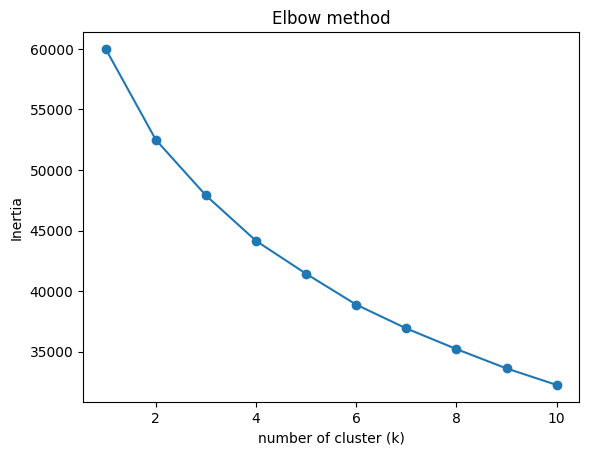

In [4]:
inertia=[]
k_range = range(1,11)

for k in k_range:
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(k_range,inertia,marker='o')
plt.title('Elbow method')
plt.xlabel('number of cluster (k)')
plt.ylabel('Inertia')
plt.show()

In [5]:
k=7
kmeans=KMeans(n_clusters=k,random_state=42)
df['cluster']=kmeans.fit_predict(df_scaled)
#display the first few rors with cluster labels
print(df.head)

<bound method NDFrame.head of       temperature   humidity  wind_speed  carbon_emissions  solar_irradiance  \
0       22.490802  52.418449   19.599966        337.165056        369.020837   
1       34.014286  49.974726    8.690240        256.681604        185.335998   
2       29.639879  40.569235   11.932794        484.024336        213.723302   
3       26.973170  66.436000   18.265613        148.540303        262.604015   
4       18.120373  58.597450   14.641787        314.535387        283.288001   
...           ...        ...         ...               ...               ...   
9995    32.153120  82.622318   24.045509        389.315259        660.200681   
9996    32.950177  32.808837   19.956484        394.037121        303.574216   
9997    33.934158  48.221908    5.389117        171.306244        774.095576   
9998    22.949760  56.599200   13.020097        245.443897        568.909821   
9999    19.342808  40.335889   10.147960        269.340664        875.536039   

      pol